# Lung Cancer Prediction — Complete Beginner ML Notebook

## Goal of this notebook

This notebook is designed for a student who has **zero prior knowledge of Machine Learning**.

We will build a classification model using the provided **Survey Lung Cancer** dataset and learn the complete ML workflow:

1. Understand the dataset
2. Load the data
3. Explore rows, columns and data types
4. Check missing values and duplicates
5. Understand the meaning of the columns
6. Clean and encode text values
7. Perform basic Exploratory Data Analysis (EDA)
8. Understand **correlation**
9. Understand **positive and negative correlation**
10. Separate features (`X`) and target (`y`)
11. Split data into training and testing sets
12. Train several classification algorithms
13. Compare model accuracy
14. Evaluate the best model
15. Understand **True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN)**
16. Generate a confusion matrix
17. Test the model on one new example
18. Save the trained model

> **Important:** This is an educational machine-learning exercise. A model trained on this small survey dataset must not be treated as a medical diagnostic system.

## 1. What is Machine Learning?

Machine Learning means teaching a computer to learn patterns from data.

For example, our dataset contains patient survey information such as:

- Age
- Smoking
- Anxiety
- Wheezing
- Coughing
- Chest pain
- Other survey responses

The dataset also contains a column called `LUNG_CANCER`.

Our job is to use the input columns to learn a pattern that can predict the target column.

### Two important words

**Feature:** An input column used by the model.

**Target:** The answer that the model is trying to predict.

In this project:

- Features = patient survey information
- Target = `LUNG_CANCER`

## 2. Import the required libraries

A library is a collection of ready-made Python tools.

We will use:

- `pandas` → work with tables/data
- `numpy` → numerical operations
- `matplotlib` → charts
- `seaborn` → statistical visualizations
- `scikit-learn` → Machine Learning algorithms and evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load the dataset

The CSV file is the data source for this project.

`read_csv()` reads a CSV file and converts it into a pandas DataFrame.

A **DataFrame** is like an Excel table inside Python.

In [2]:
df = pd.read_csv("survey lung cancer.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## 4. Understand the size of the dataset

`shape` returns:

`(number_of_rows, number_of_columns)`

The provided dataset contains 309 rows and 16 columns.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 309
Number of columns: 16


## 5. See all column names

In [5]:
print(df.columns.tolist())

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


## 6. Understand the information in each column

The original dataset uses values such as:

- `M` / `F` for gender
- `1` / `2` for many Yes/No survey questions
- `YES` / `NO` for the target

For the survey variables, the original notebook describes `1` as **No** and `2` as **Yes**.

The exact meaning of each column should always be checked before building a model.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

## 7. Statistical summary

`describe()` gives numerical statistics such as:

- count
- mean
- standard deviation
- minimum
- maximum
- quartiles

For a beginner, the most important idea is:

> `describe()` helps us understand the numerical distribution of the data.

In [7]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


## 8. Check missing values

Missing values are empty/unknown values.

`isnull().sum()` counts missing values in every column.

If a column has missing values, we need to decide how to handle them before training a model.

In [8]:
missing_values = df.isnull().sum()
print(missing_values)

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


## 9. Check duplicate rows

A duplicate means the same complete row appears more than once.

We will count duplicates before deciding whether they should be removed.

In [54]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0
Number of duplicate rows: 0


## 10. Check unique values

`unique()` shows the different values present in a column.

This is especially useful before converting text values into numbers.

In [55]:
print("Gender values:", df["GENDER"].unique())
print("Target values:", df["LUNG_CANCER"].unique())

Gender values: [1 2]
Target values: [1 0]


## 11. Understand the target variable

Our target is `LUNG_CANCER`.

It contains:

- `YES`
- `NO`

A classification model needs a numerical representation of these classes, so later we will convert:

- `YES` → 1
- `NO` → 0

Why?

Because Machine Learning algorithms work conveniently with numerical target labels.

In [45]:
print(df["LUNG_CANCER"].value_counts())

LUNG_CANCER
1    270
0     39
Name: count, dtype: int64


## 12. Basic visualization of the target

A count plot helps us see how many examples belong to each class.

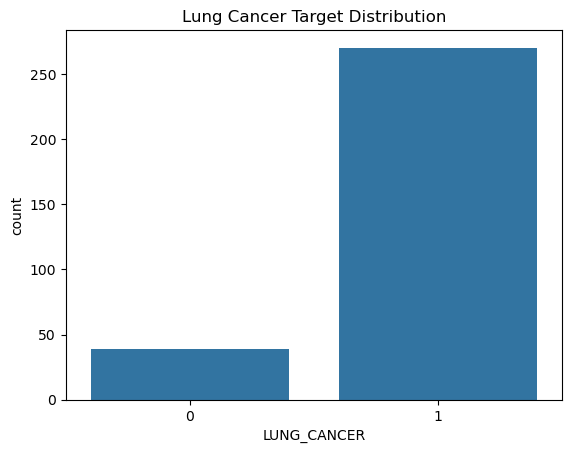

In [46]:
sns.countplot(data=df, x="LUNG_CANCER")
plt.title("Lung Cancer Target Distribution")
plt.show()

## 13. Clean column names

The original dataset contains trailing spaces in some column names, such as `FATIGUE ` and `ALLERGY `.

We can remove accidental spaces from all column names using `str.strip()`.

This prevents confusing errors later.

In [47]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


## 14. Convert Gender into numbers

The original data uses:

- `M` = Male
- `F` = Female

We will encode:

- `M` → 1
- `F` → 2

This is simply a numerical representation for the ML algorithm.

In [48]:
df["GENDER"] = df["GENDER"].replace({"M": 1, "F": 2})

print(df["GENDER"].unique())

[1 2]


## 15. Convert the target into numbers

We will convert:

- `YES` → 1
- `NO` → 0

Here we deliberately make the positive class (`1`) mean `YES`.

This becomes important when we explain TP, TN, FP and FN.

In [49]:
df["LUNG_CANCER"] = df["LUNG_CANCER"].replace({"YES": 1, "NO": 0})

print(df["LUNG_CANCER"].unique())

[1 0]


# 16. Correlation — an important concept

## What is correlation?

Correlation tells us how two numerical variables move in relation to each other.

The correlation value normally lies between **-1 and +1**.

### Positive correlation

A positive value means that, in general, when one variable increases, the other tends to increase too.

Example:

- Correlation = `+0.70`
- This is a relatively strong positive relationship.

### Negative correlation

A negative value means that, in general, when one variable increases, the other tends to decrease.

Example:

- Correlation = `-0.70`
- This is a relatively strong negative relationship.

### Near zero

A value close to `0` means there is little **linear** relationship.

### Important warning

Correlation does **not** prove that one variable causes another.

Also, correlation measures linear association. A correlation near zero does not guarantee that no other type of relationship exists.

## 17. Calculate the correlation matrix

`corr()` calculates pairwise correlations between numerical columns.

Because we have encoded Gender and the target numerically, they can also be included.

In [50]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
GENDER,1.000000,-0.021306,-0.036277,0.212959,0.152127,0.275564,0.204606,0.083560,-0.154251,-0.141207,-0.454268,-0.133303,0.064911,0.078161,-0.362958,-0.067254
AGE,-0.021306,1.000000,-0.084475,0.005205,0.053170,0.018685,-0.012642,0.012614,0.027990,0.055011,0.058985,0.169950,-0.017513,-0.001270,-0.018104,0.089465
SMOKING,-0.036277,-0.084475,1.000000,-0.014585,0.160267,-0.042822,-0.141522,-0.029575,0.001913,-0.129426,-0.050623,-0.129471,0.061264,0.030718,0.120117,0.058179
YELLOW_FINGERS,0.212959,0.005205,-0.014585,1.000000,0.565829,0.323083,0.041122,-0.118058,-0.144300,-0.078515,-0.289025,-0.012640,-0.105944,0.345904,-0.104829,0.181339
ANXIETY,0.152127,0.053170,0.160267,0.565829,1.000000,0.216841,-0.009678,-0.188538,-0.165750,-0.191807,-0.165750,-0.225644,-0.144077,0.489403,-0.113634,0.144947
PEER_PRESSURE,0.275564,0.018685,-0.042822,0.323083,0.216841,1.000000,0.048515,0.078148,-0.081800,-0.068771,-0.159973,-0.089019,-0.220175,0.366590,-0.094828,0.186388
CHRONIC DISEASE,0.204606,-0.012642,-0.141522,0.041122,-0.009678,0.048515,1.000000,-0.110529,0.106386,-0.049967,0.002150,-0.175287,-0.026459,0.075176,-0.036938,0.110891
FATIGUE,0.083560,0.012614,-0.029575,-0.118058,-0.188538,0.078148,-0.110529,1.000000,0.003056,0.141937,-0.191377,0.146856,0.441745,-0.132790,-0.010832,0.150673
ALLERGY,-0.154251,0.027990,0.001913,-0.144300,-0.165750,-0.081800,0.106386,0.003056,1.000000,0.173867,0.344339,0.189524,-0.030056,-0.061508,0.239433,0.327766
WHEEZING,-0.141207,0.055011,-0.129426,-0.078515,-0.191807,-0.068771,-0.049967,0.141937,0.173867,1.000000,0.265659,0.374265,0.037834,0.069027,0.147640,0.249300


## 18. Visualize correlation using a heatmap

A heatmap makes the correlation matrix easier to understand.

- Values closer to `+1` → stronger positive relationship
- Values closer to `-1` → stronger negative relationship
- Values closer to `0` → weak linear relationship

The diagonal will normally contain `1.0`, because every variable has perfect correlation with itself.

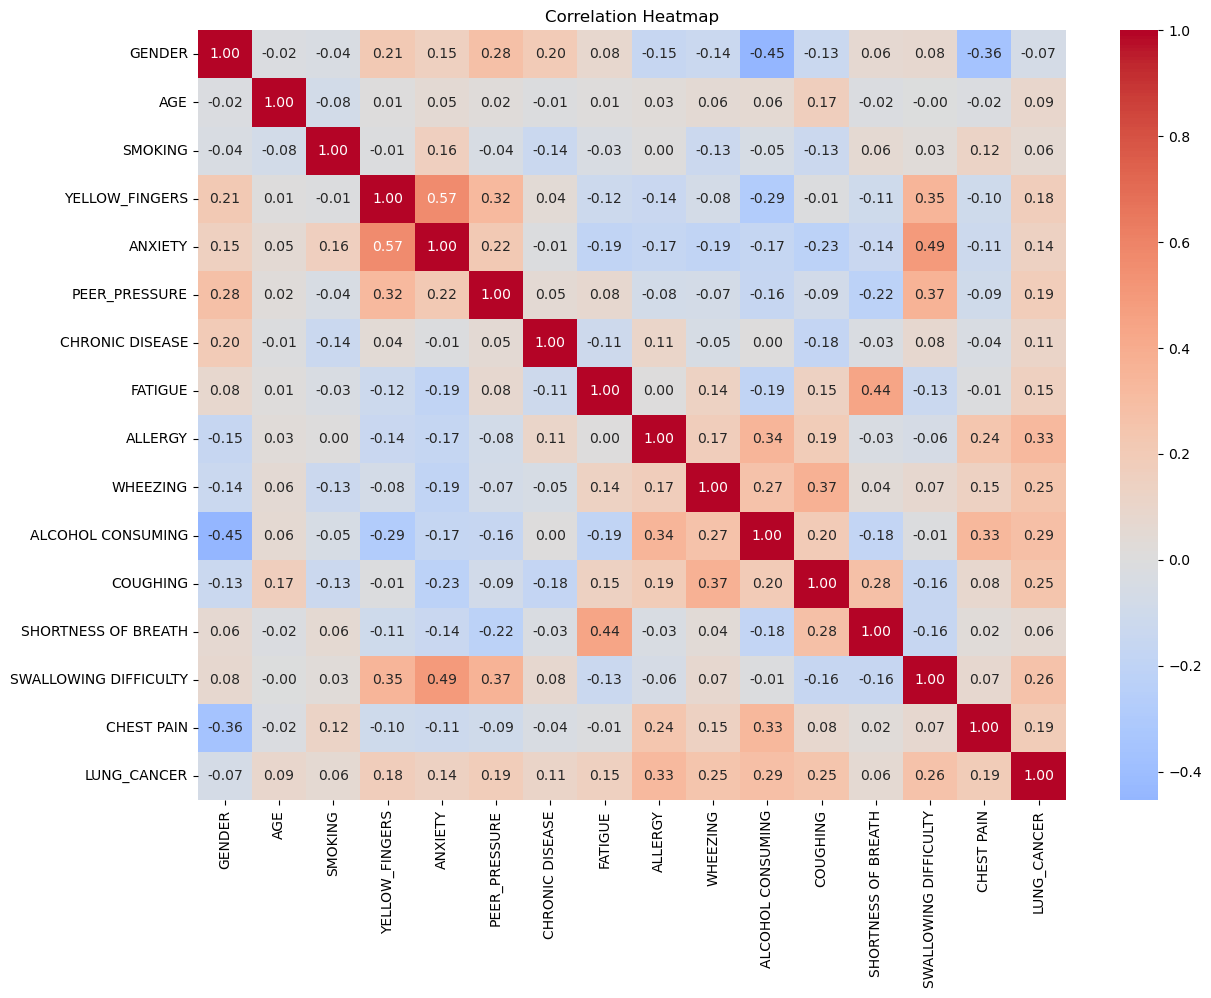

In [17]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## 19. Find correlations with the target

Instead of looking at every pair, we can specifically ask:

> How strongly is each numerical feature correlated with `LUNG_CANCER`?

This helps us understand the dataset before modeling.

In [56]:
target_correlation = correlation_matrix["LUNG_CANCER"].sort_values(ascending=False)

print(target_correlation)

LUNG_CANCER              1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
AGE                      0.089465
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
GENDER                  -0.067254
Name: LUNG_CANCER, dtype: float64


## 20. Separate positive and negative correlations with the target

This is a useful beginner exercise.

### Positive correlation with the target

These features have correlation values greater than 0.

### Negative correlation with the target

These features have correlation values less than 0.

Remember: positive/negative correlation does **not** mean "good" or "bad", and it does not prove causation.

In [19]:
positive_correlations = target_correlation[target_correlation > 0].sort_values(ascending=False)
negative_correlations = target_correlation[target_correlation < 0].sort_values()

print("POSITIVE CORRELATIONS WITH LUNG_CANCER")
print(positive_correlations)

print("\nNEGATIVE CORRELATIONS WITH LUNG_CANCER")
print(negative_correlations)

POSITIVE CORRELATIONS WITH LUNG_CANCER
LUNG_CANCER              1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
AGE                      0.089465
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
Name: LUNG_CANCER, dtype: float64

NEGATIVE CORRELATIONS WITH LUNG_CANCER
GENDER   -0.067254
Name: LUNG_CANCER, dtype: float64


## 21. Correlation with the target as a chart

The following chart shows how each feature is linearly correlated with the target.

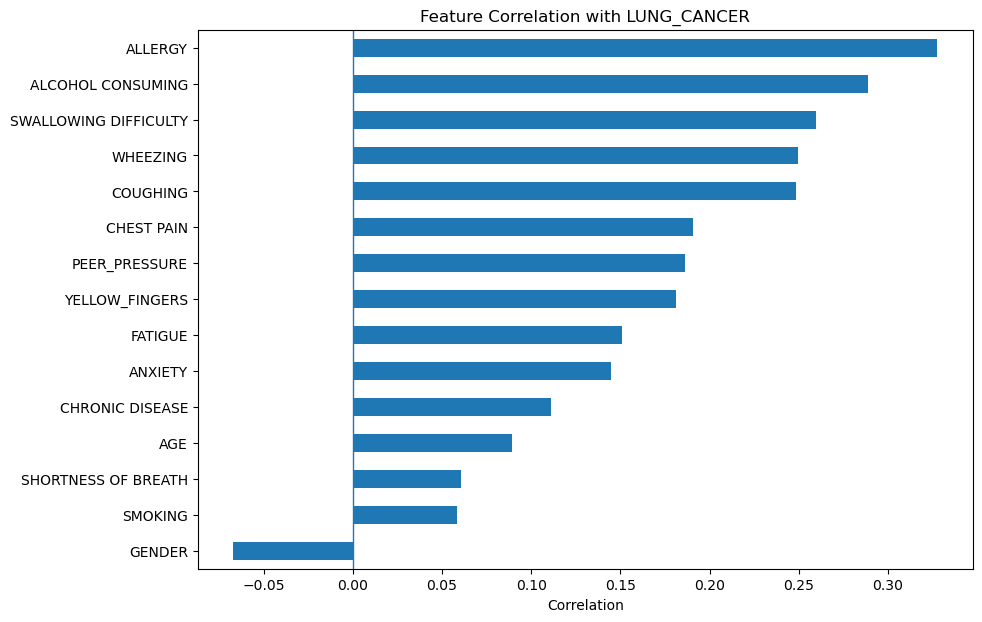

In [20]:
target_corr_without_self = target_correlation.drop("LUNG_CANCER").sort_values()

plt.figure(figsize=(10, 7))
target_corr_without_self.plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title("Feature Correlation with LUNG_CANCER")
plt.xlabel("Correlation")
plt.show()

# 22. Prepare data for Machine Learning

Now we start the actual ML process.

We need two variables:

### X — Features

`X` contains the input columns.

### y — Target

`y` contains the answer we want to predict.

In this project:

`X` = all columns except `LUNG_CANCER`

`y` = `LUNG_CANCER`

In [21]:
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (309, 15)
y shape: (309,)


## 23. Why do we split the data?

If we train and test on exactly the same data, the model may look very good simply because it has already seen those examples.

So we divide the dataset into:

- **Training data** → used to learn patterns
- **Testing data** → used to evaluate on unseen examples

We will use 80% for training and 20% for testing.

`random_state=42` makes the split reproducible.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (247, 15)
Testing features : (62, 15)
Training target  : (247,)
Testing target   : (62,)


# 24. What is Classification?

Classification means predicting a category/class.

Our classes are:

- `0` = NO
- `1` = YES

Therefore this is a **binary classification** problem.

We will compare several classification algorithms.

# 25. Model 1 — Support Vector Machine (SVM)

SVM tries to find a boundary that separates different classes.

We will train it using the training data and then make predictions on the testing data.

In [23]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8709677419354839


# 26. Model 2 — Decision Tree

A Decision Tree makes decisions using a tree-like sequence of questions.

Example idea:

`Is smoking = Yes?`

Then:

`Is wheezing = Yes?`

And so on.

The tree eventually reaches a prediction.

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9193548387096774


# 27. Model 3 — K-Nearest Neighbors (KNN)

KNN looks at nearby examples and uses their classes to make a prediction.

The basic idea is:

> Similar data points tend to have similar labels.

We will use the default settings here so students can first understand the workflow.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9032258064516129


# 28. Model 4 — Random Forest

A Random Forest combines many Decision Trees.

Instead of depending on one tree, it combines the decisions of multiple trees.

This is often a strong baseline for tabular data.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9193548387096774


# 29. Model 5 — Gradient Boosting

Gradient Boosting builds models sequentially, with later models trying to improve mistakes made by earlier models.

It is another popular classification algorithm for tabular data.

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8548387096774194


# 30. Compare all models

Now we have trained five models.

We will put their accuracy scores into one table.

### Important

Accuracy is:

`Correct predictions / Total predictions`

A high accuracy score is useful, but **accuracy alone is not enough** for understanding a classification model.

In [28]:
model_results = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        svm_accuracy,
        dt_accuracy,
        knn_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
}).sort_values("Accuracy", ascending=False)

model_results

,Model,Accuracy
1,Decision Tree,0.919355
3,Random Forest,0.919355
2,KNN,0.903226
0,SVM,0.870968
4,Gradient Boosting,0.854839


# 31. Select the best model from the comparison

For this notebook, we will select the model with the highest test accuracy.

This is only a simple educational selection rule.

In a real project, model selection should consider multiple metrics, cross-validation, class balance, data quality, and the practical cost of different errors.

In [29]:
best_model_name = model_results.iloc[0]["Model"]
print("Best model by test accuracy:", best_model_name)

Best model by test accuracy: Decision Tree


# 32. Evaluation — Why do we need more than accuracy?

Imagine a model makes these predictions:

- It correctly predicts a positive case → **True Positive**
- It correctly predicts a negative case → **True Negative**
- It predicts positive when the actual answer is negative → **False Positive**
- It predicts negative when the actual answer is positive → **False Negative**

These four values form the **confusion matrix**.

Because we defined:

- `1` = YES / positive class
- `0` = NO / negative class

we can interpret the confusion matrix clearly.

# 33. Choose the Random Forest for detailed evaluation

The original provided notebook uses Random Forest as one of its main models and saves it for later prediction.

We will therefore show a detailed evaluation for Random Forest.

The same evaluation code can be applied to any other classifier.

In [30]:
final_model = rf_model
final_predictions = rf_pred

print("Random Forest test accuracy:", accuracy_score(y_test, final_predictions))

Random Forest test accuracy: 0.9193548387096774


# 34. Confusion Matrix

A binary confusion matrix is arranged as:

| | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | TN | FP |
| Actual 1 | FN | TP |

Where:

- **TN — True Negative:** actual 0, predicted 0
- **FP — False Positive:** actual 0, predicted 1
- **FN — False Negative:** actual 1, predicted 0
- **TP — True Positive:** actual 1, predicted 1

In [31]:
cm = confusion_matrix(y_test, final_predictions)

print(cm)

[[ 6  2]
 [ 3 51]]


## 35. Extract TN, FP, FN and TP

Scikit-learn returns the binary confusion matrix in this order:

`[[TN, FP], [FN, TP]]`

We can unpack those four values.

In [33]:
tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 6
False Positive (FP): 2
False Negative (FN): 3
True Positive (TP): 51


# 36. Visualize the confusion matrix

A heatmap makes the four outcomes easier to read.

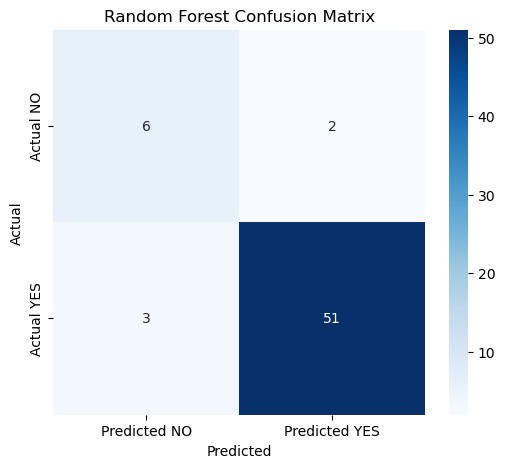

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted NO", "Predicted YES"],
    yticklabels=["Actual NO", "Actual YES"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# 37. Precision

Precision answers:

> Out of everything the model predicted as positive, how many were actually positive?

Formula:

`Precision = TP / (TP + FP)`

A higher precision means fewer false positive predictions among predicted positives.

In [35]:
precision = precision_score(y_test, final_predictions, zero_division=0)

print("Precision:", precision)

Precision: 0.9622641509433962


# 38. Recall

Recall answers:

> Out of all actual positive examples, how many did the model correctly find?

Formula:

`Recall = TP / (TP + FN)`

Recall is also called sensitivity in many classification contexts.

In [36]:
recall = recall_score(y_test, final_predictions, zero_division=0)

print("Recall:", recall)

Recall: 0.9444444444444444


# 39. F1 Score

F1 score combines precision and recall into one score.

It is the harmonic mean of precision and recall.

It is useful when we want a balance between the two.

In [37]:
f1 = f1_score(y_test, final_predictions, zero_division=0)

print("F1 Score:", f1)

F1 Score: 0.9532710280373832


# 40. Full classification report

`classification_report()` gives several useful metrics together.

We will look at:

- precision
- recall
- f1-score
- support

In [38]:
print(classification_report(
    y_test,
    final_predictions,
    target_names=["NO", "YES"],
    zero_division=0
))

              precision    recall  f1-score   support

          NO       0.67      0.75      0.71         8
         YES       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62



# 41. Understand the four prediction outcomes with a simple example

Suppose:

- Actual = 1
- Predicted = 1

This is a **True Positive**.

Suppose:

- Actual = 0
- Predicted = 0

This is a **True Negative**.

Suppose:

- Actual = 0
- Predicted = 1

This is a **False Positive**.

Suppose:

- Actual = 1
- Predicted = 0

This is a **False Negative**.

The word "True" means the prediction was correct.

The word "False" means the prediction was incorrect.

"Positive" means the model predicted class `1`.

"Negative" means the model predicted class `0`.

# 42. Test one new example

The original notebook included one sample input.

We will use the same feature structure.

The values below are survey encodings from the dataset, not medical recommendations.

In [39]:
new_data = pd.DataFrame({
    "GENDER": [1],
    "AGE": [63],
    "SMOKING": [2],
    "YELLOW_FINGERS": [2],
    "ANXIETY": [2],
    "PEER_PRESSURE": [1],
    "CHRONIC DISEASE": [1],
    "FATIGUE": [1],
    "ALLERGY": [1],
    "WHEEZING": [1],
    "ALCOHOL CONSUMING": [2],
    "COUGHING": [1],
    "SHORTNESS OF BREATH": [1],
    "SWALLOWING DIFFICULTY": [2],
    "CHEST PAIN": [2]
})

new_data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2


In [40]:
new_prediction = final_model.predict(new_data)[0]

if new_prediction == 1:
    print("Model prediction: YES (class 1)")
else:
    print("Model prediction: NO (class 0)")

Model prediction: NO (class 0)


## Important interpretation

A model prediction is **not a medical diagnosis**.

The purpose here is to demonstrate how a classification model takes input features and returns a class.

# 43. Save the trained model

`joblib.dump()` saves a trained Python/scikit-learn model to a file.

Later, the saved model can be loaded without training it again.

In [41]:
import joblib

joblib.dump(final_model, "model_joblib_lung.pkl")

print("Model saved successfully!")

Model saved successfully!


# 44. Load the saved model and test it

This demonstrates the complete save → load → predict workflow.

In [42]:
loaded_model = joblib.load("model_joblib_lung.pkl")

loaded_prediction = loaded_model.predict(new_data)

print("Prediction from loaded model:", loaded_prediction[0])

Prediction from loaded model: 0


# 45. Complete Machine Learning Workflow — Remember This

The complete workflow we followed is:

### Step 1 — Collect / load data
Read the CSV dataset.

### Step 2 — Understand the data
Look at rows, columns, types, missing values and duplicates.

### Step 3 — Clean the data
Fix column names and convert categorical text values into numerical values.

### Step 4 — Explore the data
Use counts, charts and summary statistics.

### Step 5 — Correlation
Study positive, negative and weak linear relationships.

### Step 6 — Define X and y
`X` = features  
`y` = target

### Step 7 — Train/test split
Use training data to learn and test data to evaluate.

### Step 8 — Train models
Try classification algorithms.

### Step 9 — Compare models
Use test-set accuracy as a basic comparison.

### Step 10 — Evaluate
Use confusion matrix, TP, TN, FP, FN, precision, recall and F1 score.

### Step 11 — Predict
Give new feature values to the trained model.

### Step 12 — Save
Save the trained model for later use.

This sequence is one of the most important patterns to remember when starting Machine Learning.